In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import warnings
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

path = kagglehub.dataset_download("shayanfazeli/heartbeat")
warnings.filterwarnings('ignore')
mitbih_train = pd.read_csv(path + '/mitbih_train.csv')
mitbih_test = pd.read_csv(path + '/mitbih_test.csv')

In [4]:
print(path)

C:\Users\M_work\.cache\kagglehub\datasets\shayanfazeli\heartbeat\versions\1


Linear model with MSE Loss on pytorch

In [5]:
class LinearModel(nn.Module):
    def __init__(self, input_size, output_size):
        super(LinearModel, self).__init__()
        self.linear = nn.Linear(input_size, output_size)

    def forward(self, x):
        out = self.linear(x)
        return out

In [6]:
model = LinearModel(187,1)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [7]:
epoch_count = 150
data_train, data_val = train_test_split(np.array(mitbih_train), test_size= 0.2)
X_train, y_train = data_train[:, :-1], data_train[:, -1].astype(int)

X_val, y_val = data_val[:, :-1], data_val[:, -1].astype(int)

In [8]:
loss_5 = []
loss_val5 = []

for epoch in range(epoch_count):
    optimizer.zero_grad()
    outputs = model(torch.Tensor(X_train))
    loss = criterion(outputs, torch.Tensor(y_train).unsqueeze(1))
    loss.backward()
    optimizer.step()
    if epoch % 5 == 0:
        outputs_val = model(torch.Tensor(X_val))
        loss_val = criterion(outputs_val, torch.Tensor(y_val).unsqueeze(1))
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}, Loss_val: {loss_val.item():.4f}')
        loss_5.append(loss.item())
        loss_val5.append(loss_val.item())


Epoch 0, Loss: 1.5349, Loss_val: 1.4275
Epoch 5, Loss: 1.2555, Loss_val: 1.2534
Epoch 10, Loss: 1.2162, Loss_val: 1.2214
Epoch 15, Loss: 1.1940, Loss_val: 1.2003
Epoch 20, Loss: 1.1740, Loss_val: 1.1809
Epoch 25, Loss: 1.1551, Loss_val: 1.1626
Epoch 30, Loss: 1.1370, Loss_val: 1.1451
Epoch 35, Loss: 1.1198, Loss_val: 1.1285
Epoch 40, Loss: 1.1035, Loss_val: 1.1126
Epoch 45, Loss: 1.0878, Loss_val: 1.0975
Epoch 50, Loss: 1.0729, Loss_val: 1.0830
Epoch 55, Loss: 1.0587, Loss_val: 1.0692
Epoch 60, Loss: 1.0450, Loss_val: 1.0560
Epoch 65, Loss: 1.0320, Loss_val: 1.0433
Epoch 70, Loss: 1.0195, Loss_val: 1.0312
Epoch 75, Loss: 1.0075, Loss_val: 1.0196
Epoch 80, Loss: 0.9960, Loss_val: 1.0085
Epoch 85, Loss: 0.9850, Loss_val: 0.9978
Epoch 90, Loss: 0.9744, Loss_val: 0.9875
Epoch 95, Loss: 0.9642, Loss_val: 0.9776
Epoch 100, Loss: 0.9545, Loss_val: 0.9681
Epoch 105, Loss: 0.9451, Loss_val: 0.9590
Epoch 110, Loss: 0.9360, Loss_val: 0.9502
Epoch 115, Loss: 0.9273, Loss_val: 0.9418
Epoch 120, Los

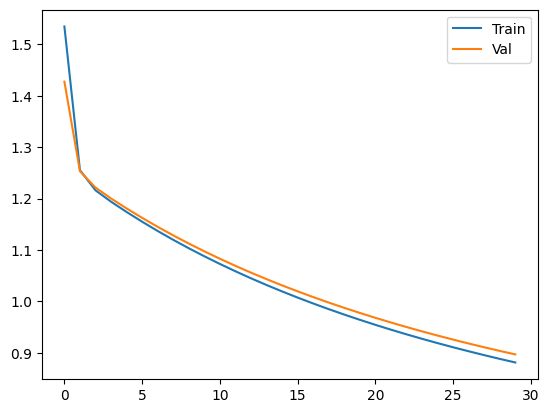

In [9]:
plt.plot(loss_5, label = 'Train')
plt.plot(loss_val5, label = 'Val')
plt.legend()

In [10]:
X_test, y_test = np.array(mitbih_test)[:, :-1], np.array(mitbih_test)[:, -1].astype(int)

In [11]:
model.eval()
with torch.no_grad():
    predicted = model(torch.Tensor(X_test))
    mse = mean_squared_error(predicted, y_test)
print(f'Final MSE: {mse:.4f}')

Final MSE: 0.8761


Basic tree boosting and forest models

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

In [13]:
model_tree = DecisionTreeClassifier()
model_boost = GradientBoostingClassifier()
model_forest = RandomForestClassifier()

In [14]:
model_tree.fit(X_train,y_train)
model_boost.fit(X_train,y_train)
model_forest.fit(X_train,y_train)

RandomForestClassifier()

In [15]:
pred_tree = model_tree.predict(X_test)
pred_boost = model_boost.predict(X_test)
pred_forest = model_forest.predict(X_test)

In [16]:
from sklearn.metrics import f1_score

Using f1 score because of our class disbalance

In [17]:
print(f"f1 metric \nTree:{f1_score(pred_tree,y_test, average='micro')}\nBoosting:{f1_score(pred_boost,y_test, average='micro')}\nForest:{f1_score(pred_forest,y_test, average='micro')}")

f1 metric 
Tree:0.9509844228221643
Boosting:0.9635009821387784
Forest:0.9730482846832031


In [ ]:
# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
class BasicModel_dd(nn.Module):
    def __init__(self,input,output):
        super().__init__()
        self.linear = nn.Sequential(
        nn.Linear(input,128),
        nn.Dropout(0.2),
        nn.ReLU(),
        nn.Linear(128,128),
        nn.Dropout(0.2),
        nn.ReLU(),
        nn.Linear(128,output),
        nn.Sigmoid()
        )
    def forward(self, x):
        out = self.linear(x)
        return out

In [23]:
def one_hot_encode(array, num_classes=5):

    one_hot_encoded = np.zeros((array.size, num_classes), dtype=int)

    one_hot_encoded[np.arange(array.size), array] = 1

    return one_hot_encoded


In [24]:
class Dataset(torch.utils.data.Dataset):

    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(one_hot_encode(y), dtype=torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx, :], self.y[idx]

In [25]:
dataset_test = Dataset(X_test, y_test)
dataset_train = Dataset(X_train,y_train)
dataset_val = Dataset(X_val,y_val)

loader_test = torch.utils.data.DataLoader(dataset_test, batch_size=64, shuffle=True)
loader_train = torch.utils.data.DataLoader(dataset_train, batch_size=64, shuffle=True)
loader_val = torch.utils.data.DataLoader(dataset_val, batch_size=64, shuffle=True)

In [27]:
model = LinearModel(187,5)
epoch_count = 10
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [29]:
for epoch in range(epoch_count):
    # Training phase
    model.train()
    train_loss = 0.0
    for inputs, targets in loader_train:
        optimizer.zero_grad()
        outputs = model(inputs)
        print(outputs,targets)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(loader_train)

    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in loader_val:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    val_loss /= len(loader_val)

    print(f'Epoch [{epoch+1}/{epoch_count}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

# Testing phase
model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs, targets in loader_test:
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        test_loss += loss.item()

test_loss /= len(loader_test)
print(f'Test Loss: {test_loss:.4f}')

print("Training and evaluation complete.")

tensor([[-0.0280, -0.1018,  0.1044,  0.1242, -0.0697],
        [ 0.0260,  0.0228,  0.0167, -0.0133, -0.2444],
        [ 0.0106, -0.0125,  0.0388,  0.0583, -0.0984],
        [ 0.0113, -0.0969,  0.0343,  0.1064, -0.1868],
        [ 0.1196, -0.0932,  0.0329, -0.1477, -0.2590],
        [ 0.0667,  0.0207, -0.0467, -0.0164, -0.3247],
        [ 0.1522,  0.3750,  0.0074, -0.1672, -0.3019],
        [ 0.0066, -0.0340,  0.0451, -0.0929, -0.1342],
        [-0.0040, -0.2364,  0.0589,  0.0429, -0.2597],
        [ 0.0985,  0.0860,  0.0358, -0.0989, -0.4167],
        [ 0.0832,  0.0631, -0.1813, -0.2146, -0.4846],
        [ 0.1536,  0.0612,  0.0058, -0.0655, -0.2411],
        [-0.0175, -0.1132,  0.0403,  0.1770, -0.2518],
        [-0.0142, -0.0851,  0.0974,  0.1538, -0.1049],
        [ 0.0936, -0.1414,  0.0547,  0.0522, -0.0489],
        [ 0.0124, -0.1149,  0.0534,  0.0007, -0.2053],
        [ 0.1239,  0.0078,  0.0321,  0.0304, -0.1757],
        [ 0.0982, -0.1839,  0.0633,  0.0776, -0.3218],
        [ 

RuntimeError: all elements of input should be between 0 and 1